# IE406 - Machine Learning
**Lab 1:** Linear Regression using Gradient Descent

**Student ID:** 202301048

### Task 1: Dataset Preparation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing

# 1. Load the dataset
california_housing = fetch_california_housing()
X = california_housing.data
y = california_housing.target

# 2. Randomly split the dataset into 3 mutually exclusive sets:
# Training Set (60%), Validation Set (20%), Test Set (20%)
np.random.seed(9432)
n_samples = X.shape[0]
indices = np.random.permutation(n_samples)

train_size = int(0.6 * n_samples)
val_size = int(0.2 * n_samples)

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

X_train, y_train = X[train_indices], y[train_indices]
X_val, y_val = X[val_indices], y[val_indices]
X_test, y_test = X[test_indices], y[test_indices]

# 3. Feature Normalization
mean_X_train = np.mean(X_train, axis=0)
std_X_train = np.std(X_train, axis=0)

X_train_norm = (X_train - mean_X_train) / std_X_train
X_val_norm = (X_val - mean_X_train) / std_X_train
X_test_norm = (X_test - mean_X_train) / std_X_train

# 4. Feature Augmentation (Add bias)
X_train_aug = np.c_[X_train_norm, np.ones(X_train_norm.shape[0])]
X_val_aug = np.c_[X_val_norm, np.ones(X_val_norm.shape[0])]
X_test_aug = np.c_[X_test_norm, np.ones(X_test_norm.shape[0])]

# 5. Standardize the Ground Truth Target values
mean_y_train = np.mean(y_train)
std_y_train = np.std(y_train)

y_train_norm = (y_train - mean_y_train) / std_y_train
y_val_norm = (y_val - mean_y_train) / std_y_train
y_test_norm = (y_test - mean_y_train) / std_y_train


### Task 2: Implement Mini-Batch Gradient Descent

In [2]:
def mini_batch_gradient_descent(X_train, y_train, X_val, y_val, lr, batch_size, max_epochs=1000, patience=100):
    n_samples, n_features = X_train.shape
    weights = np.zeros(n_features)

    best_val_mse = float('inf')
    best_weights = None
    best_epoch = -1

    train_mse_history = []
    val_mse_history = []

    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        # Shuffle training data
        indices = np.random.permutation(n_samples)
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]

        epoch_loss = 0

        # Mini-batch updates
        for i in range(0, n_samples, batch_size):
            X_batch = X_train_shuffled[i:i+batch_size]
            y_batch = y_train_shuffled[i:i+batch_size]

            # Predictions
            y_pred = X_batch.dot(weights)

            # Error
            error = y_pred - y_batch

            # MSE loss for this batch
            batch_mse = np.mean(error ** 2)
            epoch_loss += batch_mse * len(X_batch)

            # Gradients
            gradients = (2 / len(X_batch)) * X_batch.T.dot(error)

            # Update weights
            weights -= lr * gradients

        # Epoch training MSE (sample-weighted average)
        epoch_train_mse = epoch_loss / n_samples

        # Validation MSE using entire validation set
        y_val_pred = X_val.dot(weights)
        epoch_val_mse = np.mean((y_val_pred - y_val) ** 2)

        # Stop if training diverged (prevents inf/nan from reaching the loss history)
        if not np.isfinite(epoch_train_mse) or not np.isfinite(epoch_val_mse):
            break

        train_mse_history.append(epoch_train_mse)
        val_mse_history.append(epoch_val_mse)

        # Early Stopping
        if epoch_val_mse < best_val_mse:
            best_val_mse = epoch_val_mse
            best_weights = weights.copy()
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            # print(f"Early stopping at epoch {epoch}")
            break

    if best_weights is None:
        best_weights = weights.copy()
        best_epoch = max_epochs - 1

    return best_weights, best_epoch, train_mse_history, val_mse_history


### Task 3: Effect of Learning Rate

/tmp/ipykernel_1047/1433109490.py:48: RuntimeWarning: overflow encountered in square
  epoch_val_mse = np.mean((y_val_pred - y_val) ** 2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1047/1433109490.py:34: RuntimeWarning: overflow encountered in square
  batch_mse = np.mean(error ** 2)


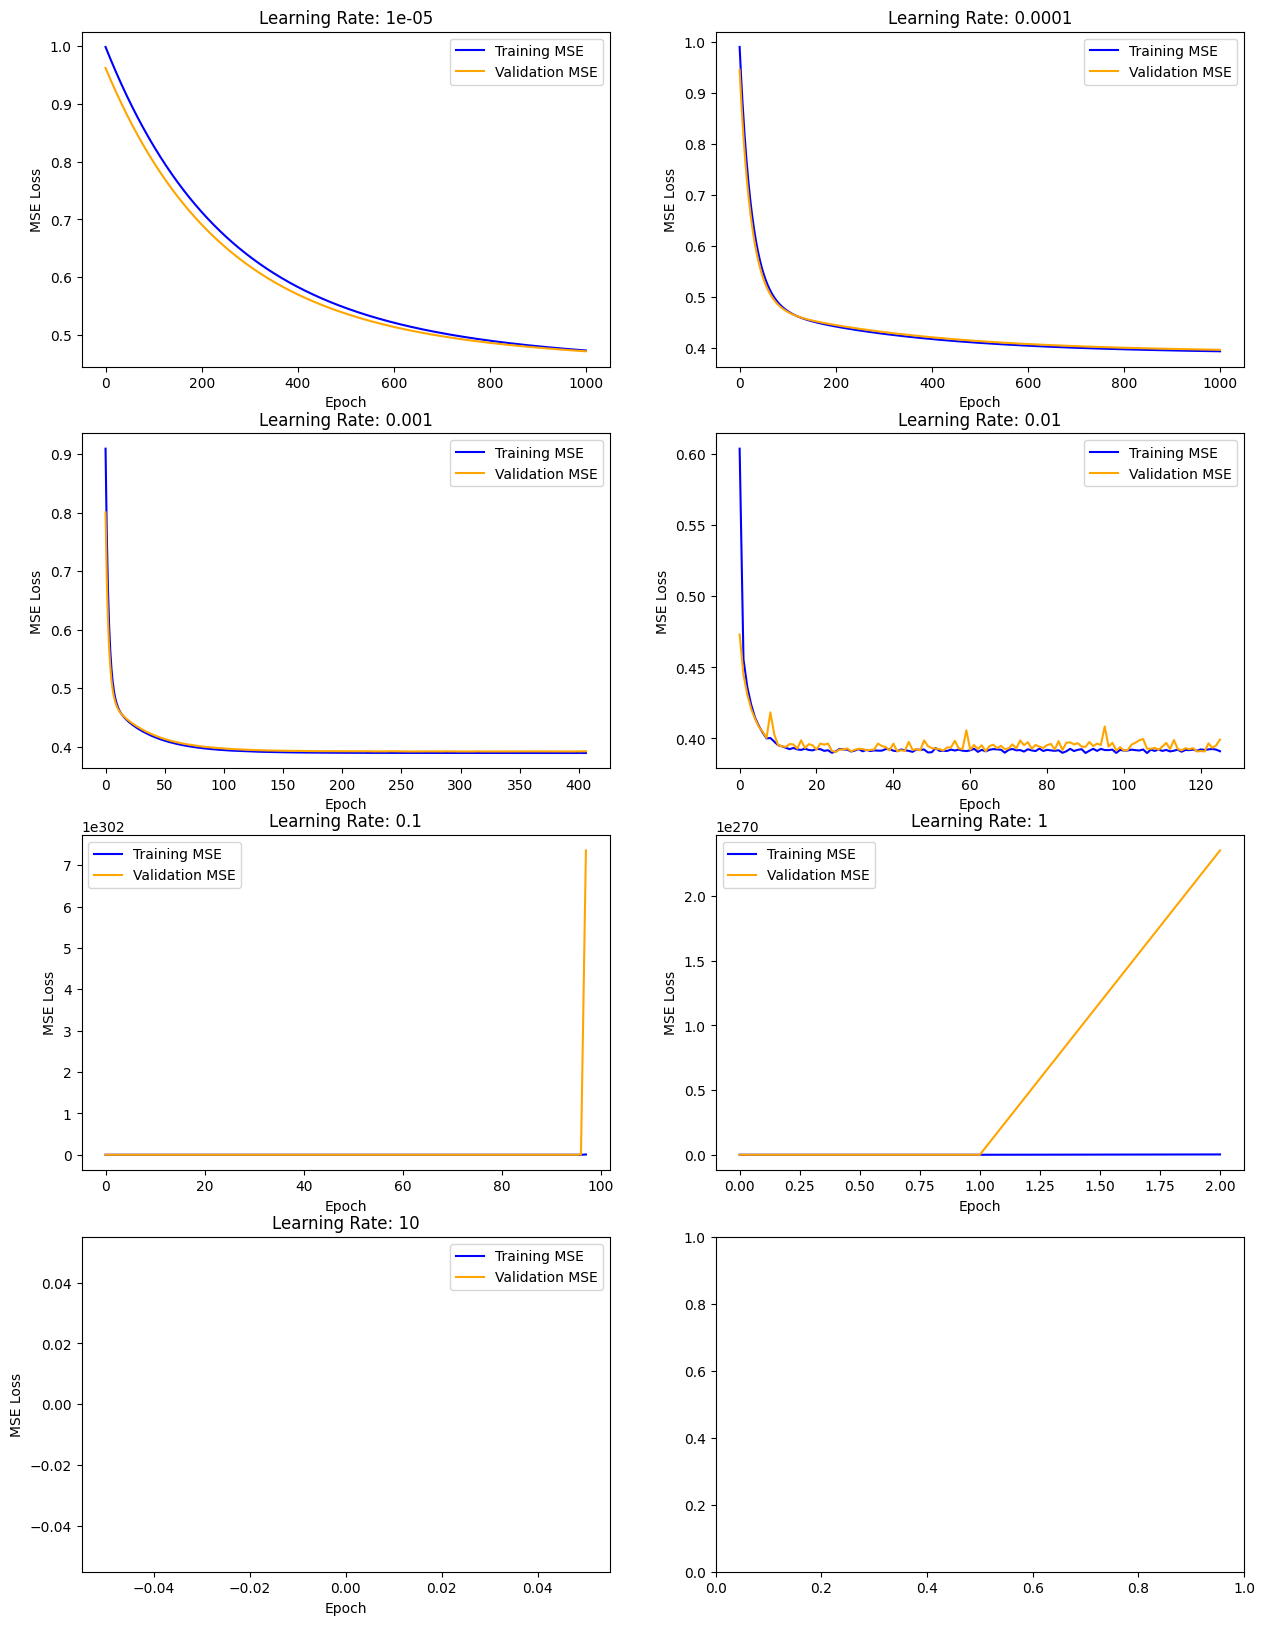

The learning rate that gives the best validation performance is: 0.01


In [3]:
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
batch_size_t3 = 128

results_t3 = {}

for lr in learning_rates:
    best_weights, best_epoch, train_mse, val_mse = mini_batch_gradient_descent(
        X_train_aug, y_train_norm, X_val_aug, y_val_norm, lr=lr, batch_size=batch_size_t3)
    results_t3[lr] = {
        'best_val_mse': min(val_mse) if val_mse else float('inf'),
        'best_epoch': best_epoch,
        'train_mse': train_mse,
        'val_mse': val_mse
    }

# Plotting
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

best_lr = None
lowest_val_mse_overall = float('inf')

for idx, lr in enumerate(learning_rates):
    train_mse = results_t3[lr]['train_mse']
    val_mse = results_t3[lr]['val_mse']

    if results_t3[lr]['best_val_mse'] < lowest_val_mse_overall:
        lowest_val_mse_overall = results_t3[lr]['best_val_mse']
        best_lr = lr

    ax = axes[idx]
    ax.plot(train_mse, label='Training MSE', color='blue')
    ax.plot(val_mse, label='Validation MSE', color='orange')
    ax.set_title(f"Learning Rate: {lr}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()

plt.show()

print(f"The learning rate that gives the best validation performance is: {best_lr}")


### Task 4: Effect of Batch Size

/tmp/ipykernel_1047/1433109490.py:35: RuntimeWarning: overflow encountered in scalar add
  epoch_loss += batch_mse * len(X_batch)
/tmp/ipykernel_1047/1433109490.py:34: RuntimeWarning: overflow encountered in square
  batch_mse = np.mean(error ** 2)
/tmp/ipykernel_1047/1433109490.py:48: RuntimeWarning: overflow encountered in square
  epoch_val_mse = np.mean((y_val_pred - y_val) ** 2)


,Batch Size,Lowest Validation MSE,Epoch
0,1,1.408759e+06,0
1,16,2.090945e+01,0
2,32,4.969836e+00,0
3,64,3.905345e-01,103
4,128,3.910387e-01,98
5,256,3.908436e-01,247
6,Entire Dataset,3.963958e-01,999


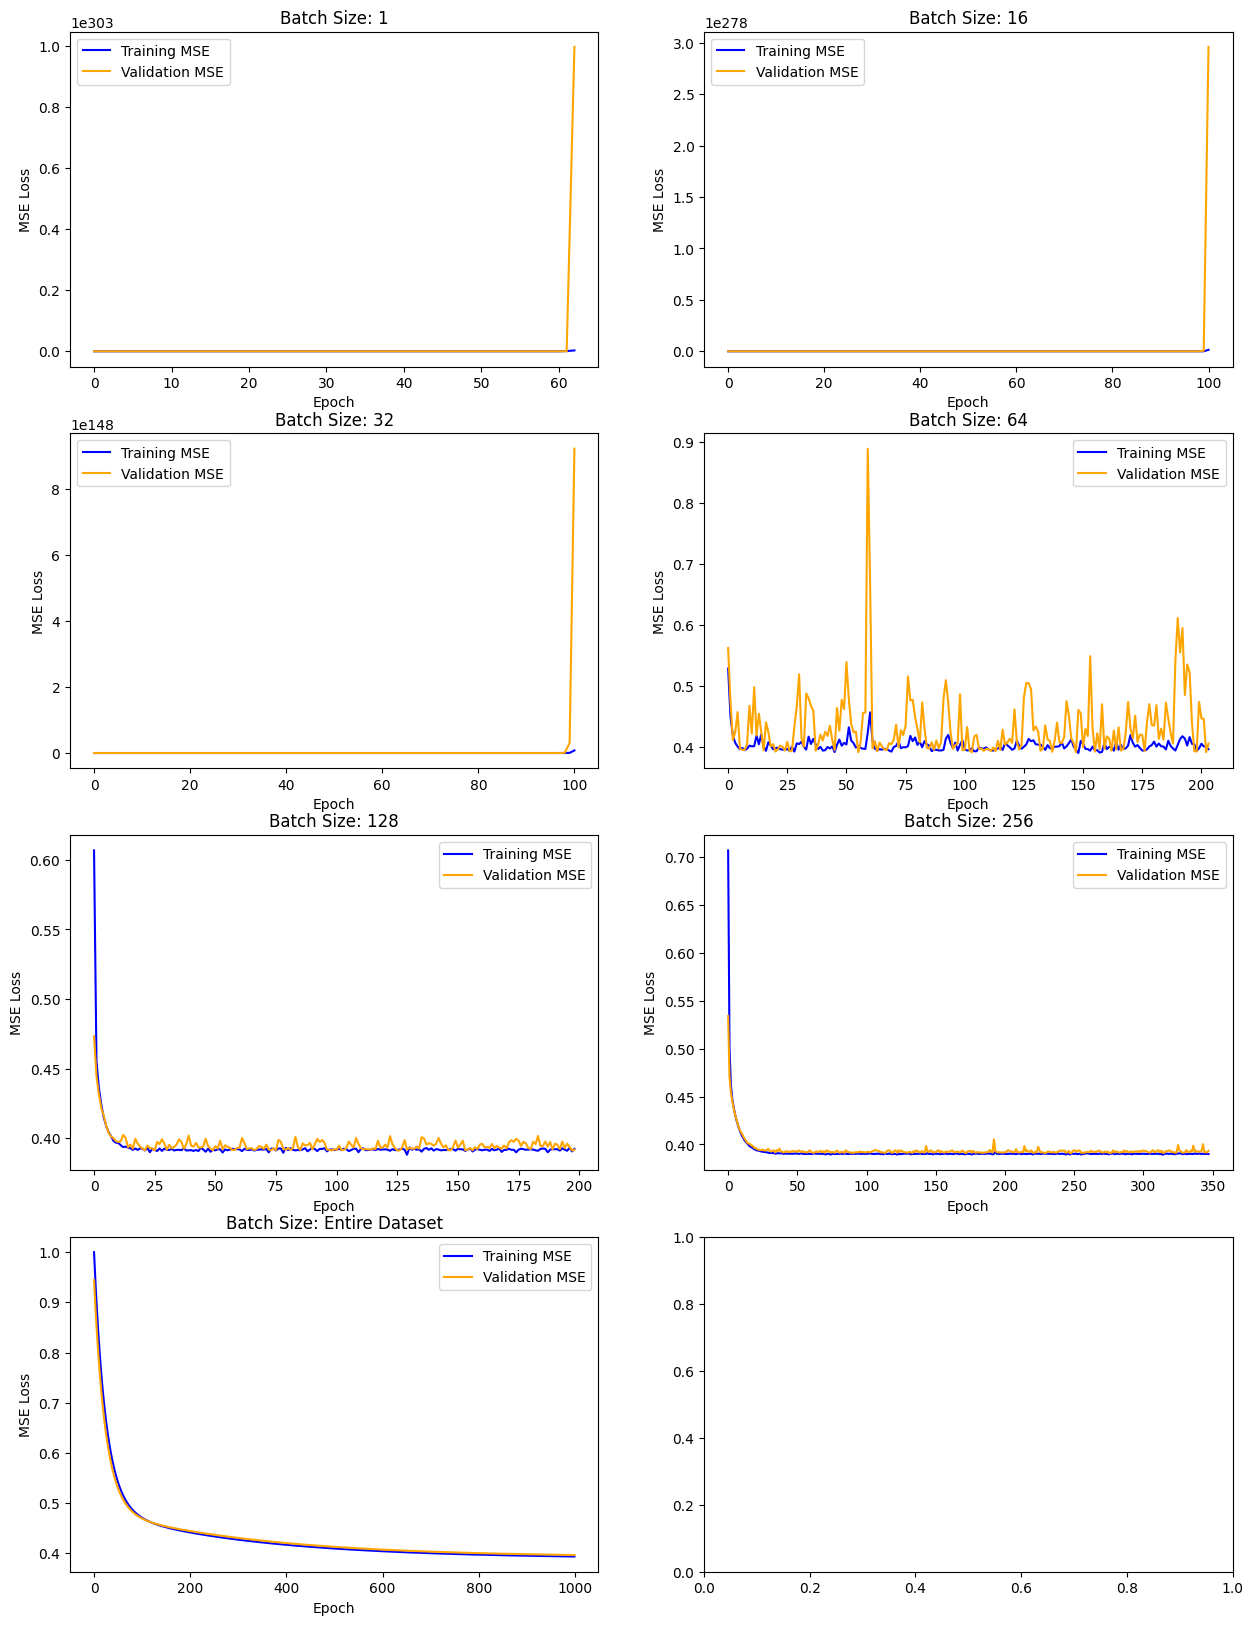

The batch size that gives the best validation performance is: 64 (64)


In [4]:
batch_sizes = [1, 16, 32, 64, 128, 256, X_train_aug.shape[0]]
batch_size_labels = ["1", "16", "32", "64", "128", "256", "Entire Dataset"]

results_t4 = []
plots_data_t4 = {}

for bs_label, bs in zip(batch_size_labels, batch_sizes):
    best_weights, best_epoch, train_mse, val_mse = mini_batch_gradient_descent(
        X_train_aug, y_train_norm, X_val_aug, y_val_norm, lr=best_lr, batch_size=bs)

    min_val = min(val_mse) if val_mse else float('inf')
    results_t4.append({
        'Batch Size': bs_label,
        'Lowest Validation MSE': min_val,
        'Epoch': best_epoch
    })

    plots_data_t4[bs_label] = {
        'train': train_mse,
        'val': val_mse
    }

# Display Table
df_results = pd.DataFrame(results_t4)
display(df_results)

# Plotting
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

best_bs = None
lowest_val_mse_bs = float('inf')

for idx, bs_label in enumerate(batch_size_labels):
    train_mse = plots_data_t4[bs_label]['train']
    val_mse = plots_data_t4[bs_label]['val']

    cur_min_val = min(val_mse) if val_mse else float('inf')
    if cur_min_val < lowest_val_mse_bs:
        lowest_val_mse_bs = cur_min_val
        best_bs = [bs for l, bs in zip(batch_size_labels, batch_sizes) if l == bs_label][0]

    ax = axes[idx]
    ax.plot(train_mse, label='Training MSE', color='blue')
    ax.plot(val_mse, label='Validation MSE', color='orange')
    ax.set_title(f"Batch Size: {bs_label}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()

plt.show()

print(f"The batch size that gives the best validation performance is: {best_bs} ({df_results.loc[df_results['Lowest Validation MSE'].idxmin()]['Batch Size']})")


### Task 5: Inference on Test Set

,RMSE,MAPE (%),MAE,R-squared
Training,0.72339,31.40857,0.52694,0.60937
Validation,0.72343,31.25199,0.53160,0.59493
Test,0.72963,31.08291,0.53015,0.60441


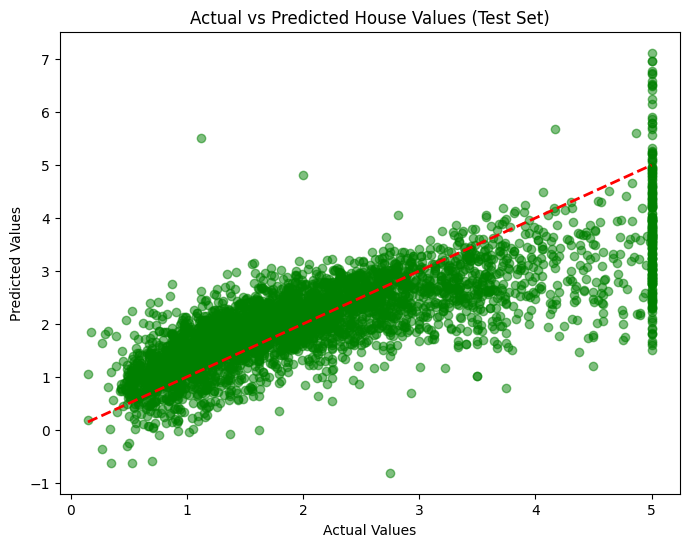

In [5]:
# 1. Train final model with best parameters
best_weights, best_epoch, train_mse, val_mse = mini_batch_gradient_descent(
    X_train_aug, y_train_norm, X_val_aug, y_val_norm, lr=best_lr, batch_size=best_bs)

# 2. Evaluate performance
def calculate_metrics(X, y_true_orig, weights, mean_y, std_y):
    # Predict in standardized space
    y_pred_norm = X.dot(weights)

    # Map back to original space
    y_pred_orig = (y_pred_norm * std_y) + mean_y

    # Calculate metrics
    error = y_true_orig - y_pred_orig
    rmse = np.sqrt(np.mean(error ** 2))
    mape = np.mean(np.abs(error / y_true_orig)) * 100
    mae = np.mean(np.abs(error))

    ss_res = np.sum(error ** 2)
    ss_tot = np.sum((y_true_orig - np.mean(y_true_orig)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    return [rmse, mape, mae, r2], y_pred_orig

metrics_train, _ = calculate_metrics(X_train_aug, y_train, best_weights, mean_y_train, std_y_train)
metrics_val, _ = calculate_metrics(X_val_aug, y_val, best_weights, mean_y_train, std_y_train)
metrics_test, y_test_pred = calculate_metrics(X_test_aug, y_test, best_weights, mean_y_train, std_y_train)

# Report metrics in table
metrics_df = pd.DataFrame([metrics_train, metrics_val, metrics_test],
                          columns=['RMSE', 'MAPE (%)', 'MAE', 'R-squared'],
                          index=['Training', 'Validation', 'Test'])
metrics_df = metrics_df.round(5)
display(metrics_df)

# 3. Plot Actual vs Predicted values using a scatter plot for Test Set
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Actual vs Predicted House Values (Test Set)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()
